# STREAM trajectory — male donor

In [ ]:
# Dataset locations for this notebook come from ../datasets.yaml.
# Edit that file to point at your own copies -- do not hardcode paths below.
# DatasetPaths.find() walks up from the kernel's working directory to the first
# datasets.yaml (or uses $FOCAL_DATASETS), so it works wherever Jupyter was started.
from focal.io import DatasetPaths

config = DatasetPaths.find()


In [2]:
!hostname

cn093.delta.ncsa.illinois.edu


In [3]:
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
# Saving plots with editable text
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)

import os
import sys
import logging

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

figure_params = {
    'dpi': 300, 
    'bbox_inches': 'tight', 
    'format': 'svg', 
    'transparent': True
}

plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": 'none'
})

In [ ]:
#adata_infile = config.MALE_STREAM_INPUT
#barcodes_dir = config.MALE_SLIDE_BARCODES
stream_object = config.VELOCITY_STREAM_TRAJ
# out_objects = config.MALE_OBJECTS
out_tmp = config.VELOCITY_TMP

# where the "Dictys inputs" section below writes: STREAM branch/edge/dist tables and
# the dictys data folder (clusters.csv, coord_rna.tsv.gz)
stream_outs_path = config.VELOCITY_STREAM_OUTS
dictys_data_path = config.DICTYS_DATA


In [5]:
!rsync -aP $stream_object /dev/shm/

sending incremental file list
stream_traj_v6.pkl
  1,104,547,653 100%  165.44MB/s    0:00:06 (xfr#1, to-chk=0/1)


In [8]:
from os.path import basename
import stream as st
#read the stream result file pkl or h5ad
adata = st.read(file_name='/dev/shm/' + os.path.basename(stream_object), workdir=out_tmp)
# mlle_traj = st.read(file_name='/dev/shm/' + os.path.basename(mlle_traj), workdir=out_tmp)

Working directory is already specified as '/tmp/tmptccf43nu' 
To change working directory, please run set_workdir(adata,workdir=new_directory)


In [9]:
adata

AnnData object with n_obs × n_vars = 28494 × 3018
    obs: 'cell_type_major', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11', 'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17', 'topic_18', 'topic_19', 'topic_20', 'topic_21', 'topic_22', 'topic_23', 'topic_24', 'topic_25', 'topic_26', 'topic_27', 'topic_28', 'topic_29', 'topic_30', 'topic_31', 'leiden', 'sub_cell_type', 'final_cell_colors', 'D2_per_BATF', 'D2_per_IRF4', 'D2_per_SPIB', 'D2_per_PRDM1', 'D2_per_IRF8', 'D4_per_BATF', 'D4_per_IRF4', 'D4_per_SPIB', 'D4_per_PRDM1', 'D4_per_IRF8', 'kmeans', 'node', 'branch_id', 'branch_id_alias', 'branch_lam', 'branch_dist', 'S0_pseudotime', 'S3_pseudotime', 'S2_pseudotime', 'S1_pseudotime', 'window1', 'window2', 'window3', 'window4', 'window194', 'window147', 'Z11', 'Z3', 'score_G1S', 'score_G2M', 'score_m

In [11]:
adata.obs['branch_id_alias']

index
AAACAGCCAAGCCACT-3    (S3, S0)
AAACAGCCAAGGTGCA-1    (S1, S0)
AAACAGCCAAGTTATC-1    (S1, S0)
AAACAGCCAATAGCCC-1    (S1, S0)
AAACAGCCAGTTAGCC-1    (S1, S0)
                        ...   
TTTGTTGGTTTACGTC-1    (S1, S0)
TTTGTTGGTTTAGTCC-1    (S1, S0)
TTTGTTGGTTTATGGG-2    (S1, S0)
TTTGTTGGTTTCCTCC-3    (S3, S0)
TTTGTTGGTTTGAGGC-2    (S2, S0)
Name: branch_id_alias, Length: 28494, dtype: object

In [13]:
adata.obs['S0_pseudotime']

index
AAACAGCCAAGCCACT-3    0.002726
AAACAGCCAAGGTGCA-1    0.000901
AAACAGCCAAGTTATC-1    0.001252
AAACAGCCAATAGCCC-1    0.001403
AAACAGCCAGTTAGCC-1    0.001313
                        ...   
TTTGTTGGTTTACGTC-1    0.001433
TTTGTTGGTTTAGTCC-1    0.001554
TTTGTTGGTTTATGGG-2    0.000273
TTTGTTGGTTTCCTCC-3    0.002681
TTTGTTGGTTTGAGGC-2    0.000115
Name: S0_pseudotime, Length: 28494, dtype: float64

#### Code to merge obs from one traj/adata to another

In [6]:
# # Reset index to make barcode a column for merging
# df_source = mlle_traj.obs[['score_G1S', 'score_G2M', 'score_myc_up']].reset_index()
# df_target = adata.obs.reset_index()
# # Merge on the barcode (usually index, often called 'index' after reset)
# merged = pd.merge(
#     df_target,
#     df_source,
#     on='index',
#     how='left'  # or 'inner' if you want only matching barcodes
# )
# # Set index back to barcode
# merged = merged.set_index('index')
# # Assign back to adata_target.obs
# adata.obs = merged
# st.write(adata,file_name=os.path.join(out_objects,'stream_traj_v6.pkl'))

#### Add obs of interest

In [6]:
window_1_barcodes = f"{config.TMP_DYNAMIC}/Subset1/names_rna.txt"
window_2_barcodes = f"{config.TMP_DYNAMIC}/Subset2/names_rna.txt"
window_3_barcodes = f"{config.TMP_DYNAMIC}/Subset3/names_rna.txt"
window_4_barcodes = f"{config.TMP_DYNAMIC}/Subset4/names_rna.txt"
window_194_barcodes = f"{config.TMP_DYNAMIC}/Subset194/names_rna.txt"
windows_147_barcodes = f"{config.TMP_DYNAMIC}/Subset147/names_rna.txt"

In [6]:
# latent factor values
z_matrix = config.Z_MATRIX_GC_PB
z_matrix_predisposition = config.Z_MATRIX_PREDISPOSED

In [8]:
import pandas as pd
# Read barcodes from each window file and create DataFrames
window_files = {
    'window1': window_1_barcodes,
    'window2': window_2_barcodes,
    'window3': window_3_barcodes,
    'window4': window_4_barcodes,
    'window194': window_194_barcodes,
    'window147': windows_147_barcodes
}

# Create DataFrames for each window
for window_name, file_path in window_files.items():
    # Read barcodes from file
    df = pd.read_csv(file_path, header=None, names=['Barcode'])
    # Create a new column with window name, set to the window name for all rows
    df[window_name] = window_name
    # Set barcode as index
    df = df.set_index('Barcode')
    
    # Add to adata.obs, merging on index (cell barcodes)
    # This will automatically set NaN for cells not in the window
    adata.obs = adata.obs.join(df[window_name])
    
    # Convert to categorical with NA for missing values
    adata.obs[window_name] = adata.obs[window_name].astype('category')

In [16]:
import pandas as pd
z_matrix_df = pd.read_csv(z_matrix_predisposition)
z_matrix_df = z_matrix_df.set_index('Unnamed: 0')
# get the columns for Zs in a separate df
z_score_df = z_matrix_df['Z5']
#rename the column to PRDM1_Z5
z_score_df = z_score_df.rename('PRDM1_Z5')

In [17]:
display(z_score_df)

Unnamed: 0
AAACCTGAGAGCAATT-1    0.873929
AAACCTGAGATGTTAG-1   -0.732540
AAACCTGAGCCGATTT-1   -0.458578
AAACCTGCACGCCAGT-1   -0.508582
AAACGGGAGAGCTTCT-1   -0.754420
                        ...   
TTTGTCAAGGGCTCTC-1   -0.884464
TTTGTCACAATCTGCA-1   -0.864181
TTTGTCAGTCCCTTGT-1   -0.705222
TTTGTCAGTGATGTCT-1   -0.770769
TTTGTCAGTGTATGGG-1   -0.673088
Name: PRDM1_Z5, Length: 3298, dtype: float64

In [18]:
# Check overlap
common = adata.obs.index.intersection(z_score_df.index)
print(f"Matching cells: {len(common)} out of {len(adata.obs)}")

Matching cells: 0 out of 28494


In [ ]:
# add the lf_gc_pb_df to adata.obs
adata.obs = adata.obs.join(z_score_df)
# convert the lf_gc_pb_df to categorical
adata.obs[['PRDM1_Z5']] = adata.obs[['PRDM1_Z5']].astype('category')

In [15]:
adata.obs['PRDM1_Z5'].notna().sum()

0

In [25]:
# get the cell counts per cell type
cell_counts = adata.obs['sub_cell_type'].value_counts()
cell_counts

ActB-1       5283
ActB-2       4647
ActB-4       4440
GC-1         4365
ActB-3       3984
GC-2         2515
PB-2         2345
earlyPB       657
earlyActB     258
Name: sub_cell_type, dtype: int64

In [5]:
# add an obs column which is the same for all cells and says gray
adata.obs['gray'] = 'gray'

# Run stream dim reduction (LLE) on the anndata, with imputed gene expression and filtered cells

In [6]:
#set the imputed gene expression as the accessible data layer
adata.X = adata.layers['MAGIC_imputed_data']

In [16]:
# # Setting var_genes if you need to select top 3k genes from a list of more than 3k genes
# st.select_variable_genes(adata,loess_frac=0.01,percentile=80)

In [17]:
# # 'var_genes' vs 'all' : use top % or all genes from .var ; if using all make sure the adata is subsetted to only the highly variable genes
# # n_components = Number of branches present in your biological differentation
# st.dimension_reduction(adata,method='mlle',feature='var_genes',n_components=2,n_neighbors=30,n_jobs=64) # using the same knn as diffusion maps (default is 30)

#### Order cell types based on how you think the pseudotime should be

In [ ]:
# # Order the cell states for plotting (colors need to be categorical)
# adata.obs['cell_type_annotation'] = pd.Categorical(
#     adata.obs['cell_type_annotation'],
#     categories=['early_ActB', 'ActB_1', 'ActB_2', 'ActB_3', 'ActB_4', 'GC_1', 'GC_2', 'early_PB', 'PB_1'],
#     ordered=True
# )
# # Create a new column in adata.obs for colors
# adata.obs['final_cell_colors'] = adata.obs['cell_type_annotation'].map(leiden_color_dict)

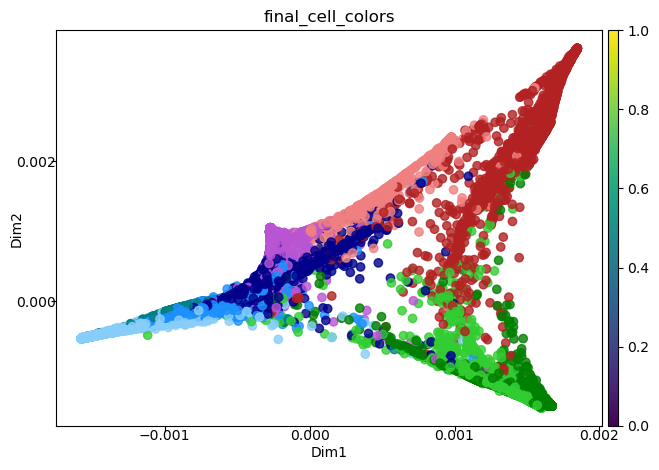

In [10]:
leiden_color_dict = {
    'ActB-1': '#87CEFA',     # lightskyblue
    'ActB-2': '#1E90FF',     # dodgerblue
    'ActB-4': '#9370DB',     # mediumorchid
    'GC-1': '#7BDE7B',       # custom light green
    'ActB-3': '#00008B',     # darkblue
    'GC-2': '#008000',       # green
    'PB-2': '#BB3636',       # custom red
    'earlyPB': '#F08080',    # lightcoral
    'earlyActB': '#008080'   # teal
}
st.plot_dimension_reduction(adata, color=['final_cell_colors'], n_components=2)

# Visualize the UMAP with selected cells

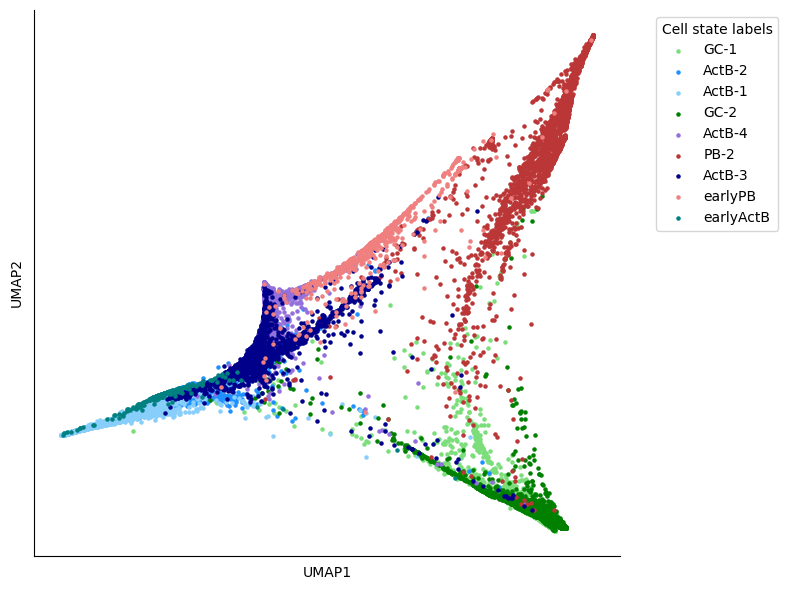

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Extract UMAP coordinates from the 'X_dr'/'X_mlle' slot 
umap_coords = adata.obsm['X_dr']

# Extract the labels for coloring
labels = adata.obs['sub_cell_type']

# Get unique labels and their corresponding colors
unique_labels = labels.unique()
color_list = [leiden_color_dict[label] for label in unique_labels]

# Plotting the UMAP with colors based on labels
plt.figure(figsize=(8, 6))

for label, color in zip(unique_labels, color_list):
    idx = labels == label
    plt.scatter(umap_coords[idx, 0], umap_coords[idx, 1], c=color, label=label, s=5)  # s=5 sets the marker size to 5 points
# Remove ticks
plt.xticks([])
plt.yticks([])
# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.title('')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(title="Cell state labels", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
# plt.savefig(f"{config.MALE_STREAM_FIGURES}/bifurcation_male.pdf", 
#             bbox_inches='tight',  # Ensures the legend isn't cut off
#             dpi=300,             # High resolution
#             format='pdf')        # Specify PDF format
plt.show()

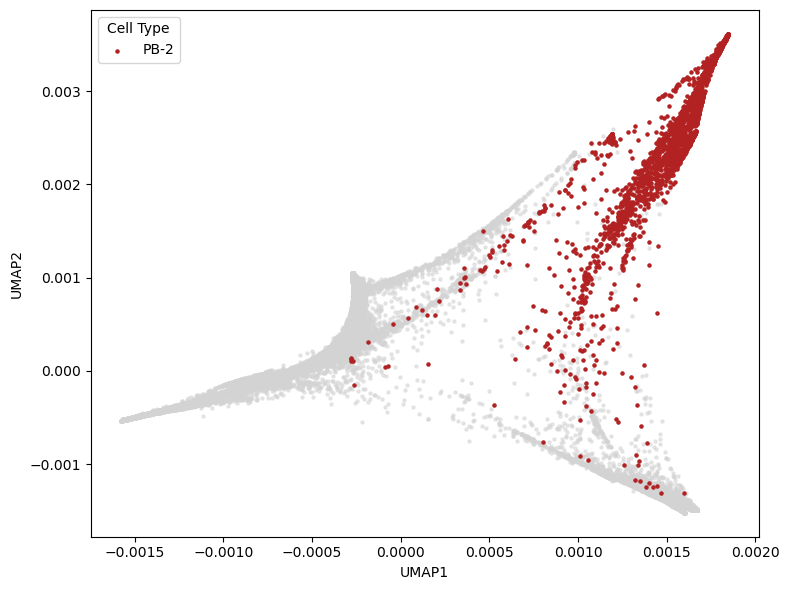

In [17]:
# Extract UMAP coordinates from the 'X_dr' slot 
umap_coords = adata.obsm['X_dr']

# Extract the labels for coloring
labels = adata.obs['sub_cell_type']

# Define colors
highlight_color = 'firebrick'  # Original PB-2 color
background_color = '#D3D3D3'  # Light gray

# Create the plot
plt.figure(figsize=(8, 6))

# Plot background (all non-PB-2 cells) first
background_mask = labels != 'PB-2'
plt.scatter(umap_coords[background_mask, 0], umap_coords[background_mask, 1], 
           c=background_color, s=5, alpha=0.5)

# Plot PB-2 cells
actb4_mask = labels == 'PB-2'
plt.scatter(umap_coords[actb4_mask, 0], umap_coords[actb4_mask, 1], 
           c=highlight_color, s=5, label='PB-2')

plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(title="Cell Type", loc='upper left')
plt.tight_layout()
plt.show()

### Viz LF score on the traj

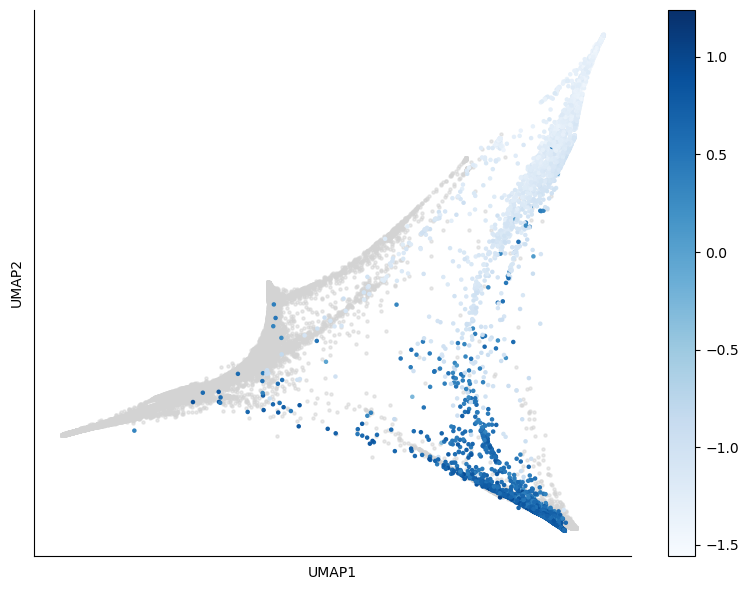

In [14]:
# Extract UMAP coordinates from the 'X_dr' slot 
umap_coords = adata.obsm['X_dr']

# Replace 'score_column' with your actual score column name
z11_score = adata.obs['Z11']  

# Create the plot
plt.figure(figsize=(8, 6))

# Plot background (cells with NaN scores) first
background_mask = z11_score.isna()
plt.scatter(umap_coords[background_mask, 0], umap_coords[background_mask, 1], 
           c='#D3D3D3', s=5, alpha=0.5) #gray background

# Create custom light blue to dark blue colormap
# custom_cmap = LinearSegmentedColormap.from_list(
#        "custom_blue", ["#E6F3FF", "#003366"]  # Very light blue to very dark blue
#    )
# Plot cells with scores using a colormap
score_mask = ~z11_score.isna()
scatter = plt.scatter(umap_coords[score_mask, 0], umap_coords[score_mask, 1], 
                     c=z11_score[score_mask], s=5, 
                     cmap='Blues')
# Remove ticks
plt.xticks([])
plt.yticks([])
# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.title('')
# Add colorbar
plt.colorbar(scatter, label='')
plt.title('')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.tight_layout()
# plt.savefig(f"{config.MALE_STREAM_FIGURES}/Z11_male_traj.pdf", 
#             bbox_inches='tight',  # Ensures the legend isn't cut off
#             dpi=300,             # High resolution
#             format='pdf')
plt.show()

#### Viz window specific cells

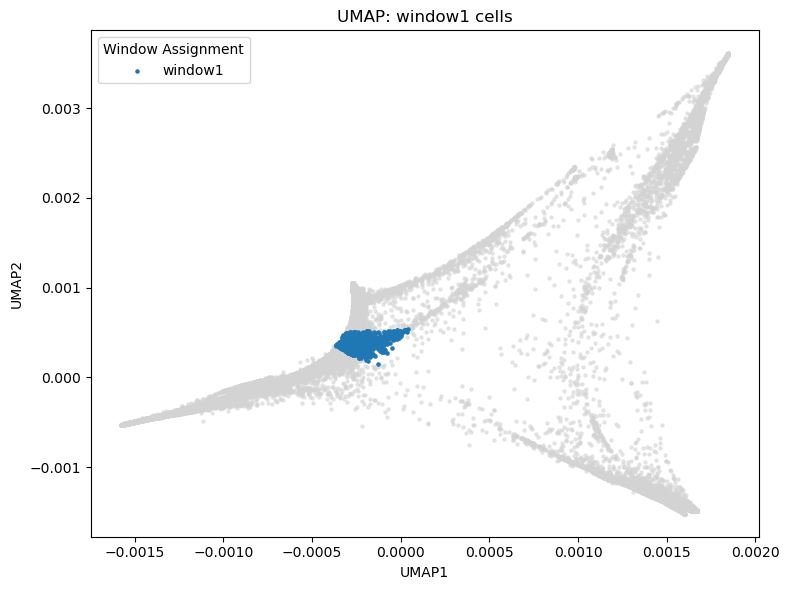

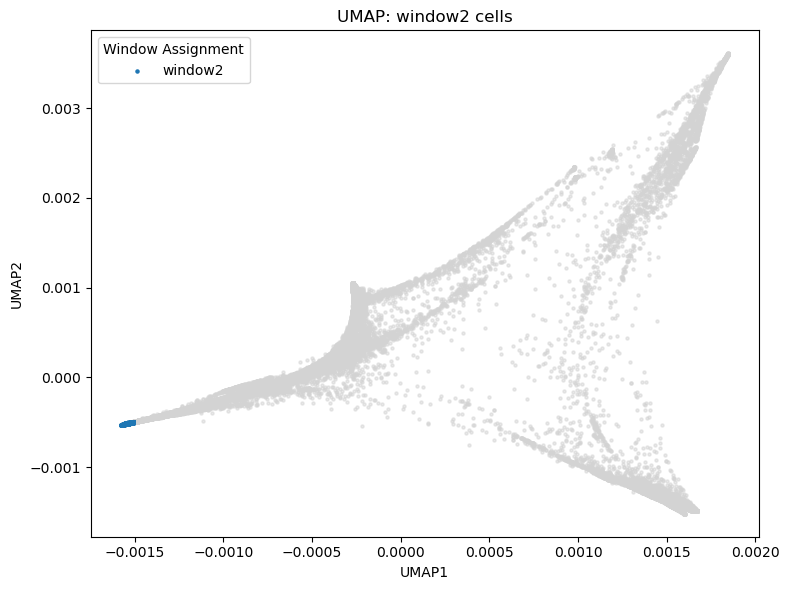

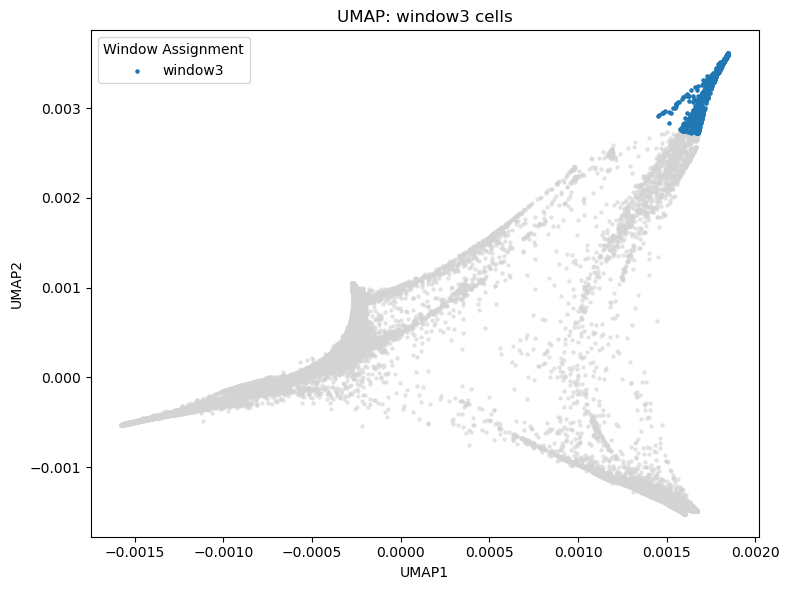

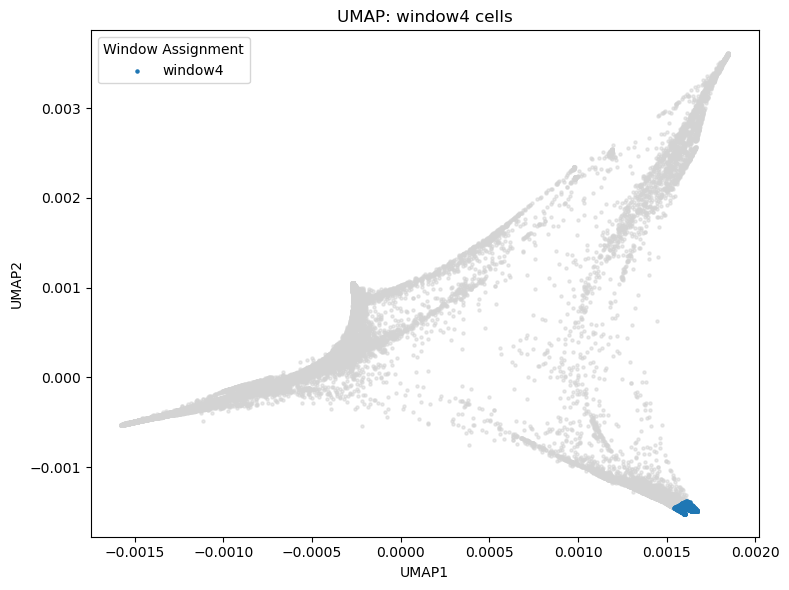

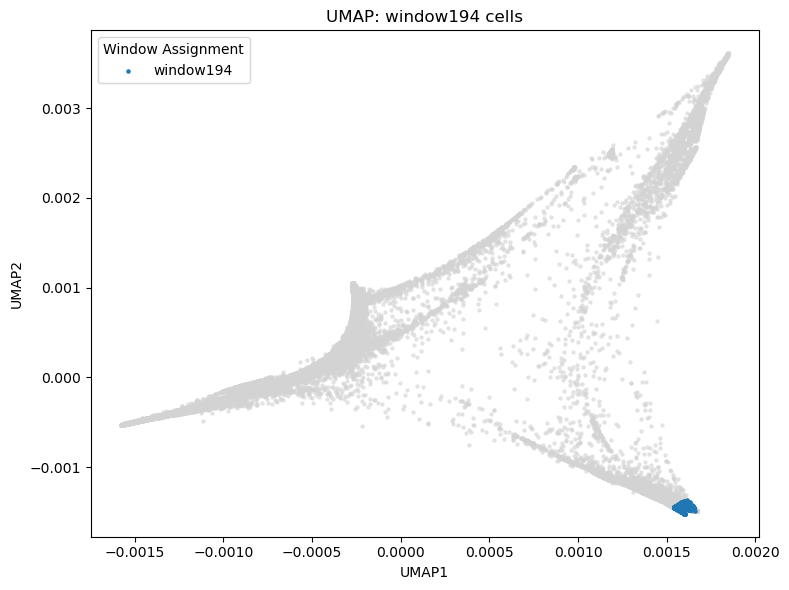

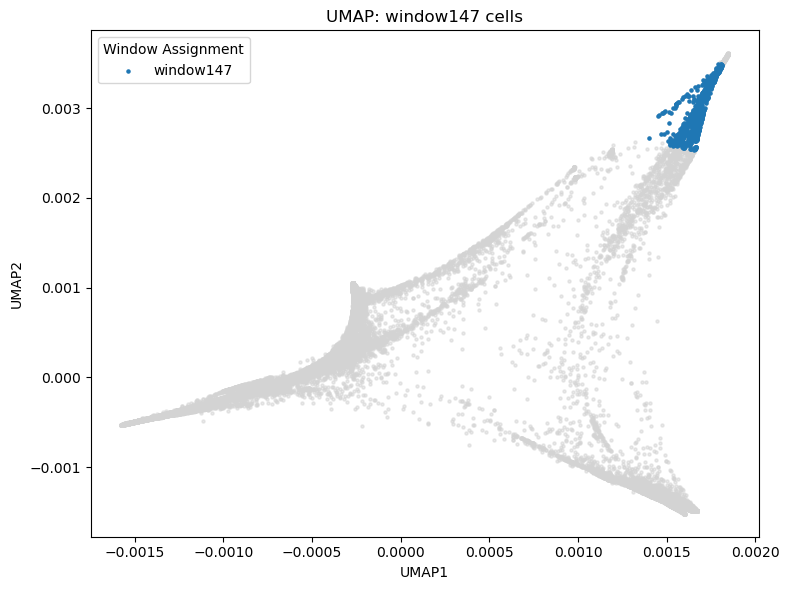


Number of cells in each window:
window1: 1000 cells
window2: 1000 cells
window3: 1000 cells
window4: 1000 cells
window194: 1000 cells
window147: 1000 cells


In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Extract UMAP coordinates from the 'X_dr' slot 
umap_coords = adata.obsm['X_dr']

# Define colors
highlight_color = '#1f77b4'  # Blue for highlighted cells
background_color = '#D3D3D3'  # Light gray for background

# Get all window columns
window_columns = ['window1', 'window2', 'window3', 'window4', 'window194', 'window147']

# Create a plot for each window
for window in window_columns:
    plt.figure(figsize=(8, 6))
    
    # Plot background (all cells) first
    plt.scatter(umap_coords[:, 0], umap_coords[:, 1], 
               c=background_color, s=5, alpha=0.5)
    
    # Plot cells assigned to this window
    window_mask = ~adata.obs[window].isna()  # True for cells in this window
    if window_mask.any():  # Only plot if there are cells in this window
        plt.scatter(umap_coords[window_mask, 0], umap_coords[window_mask, 1], 
                   c=highlight_color, s=5, label=window)
    
    plt.title(f'UMAP: {window} cells')
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    plt.legend(title="Window Assignment", loc='upper left')
    plt.tight_layout()
    plt.show()

# Print statistics
print("\nNumber of cells in each window:")
for window in window_columns:
    n_cells = (~adata.obs[window].isna()).sum()
    print(f"{window}: {n_cells} cells")

In [39]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Extract UMAP coordinates from the 'X_dr' slot 
# umap_coords = adata.obsm['X_dr']

# # Extract the labels for coloring
# labels = adata.obs['cell_type_major']

# # Get unique labels
# unique_labels = labels.unique()

# # Define a color for the highlighted cells and for the background cells
# highlight_color = '#1f77b4'  # A shade of blue
# background_color = '#D3D3D3'  # Light gray

# # Create a plot for each unique label
# for label in unique_labels:
#     plt.figure(figsize=(8, 6))
    
#     # Plot background (gray) points first
#     plt.scatter(umap_coords[:, 0], umap_coords[:, 1], c=background_color, s=5, alpha=0.5)
    
#     # Plot highlighted points
#     idx = labels == label
#     plt.scatter(umap_coords[idx, 0], umap_coords[idx, 1], c=highlight_color, s=5, label=label)

#     plt.title(f'UMAP: {label} cells highlighted')
#     plt.xlabel('UMAP1')
#     plt.ylabel('UMAP2')
#     plt.legend(title="Highlighted Cells", loc='upper left')
#     plt.tight_layout()
#     plt.show()

# Trajectory inference by fitting elastic graph

In [30]:
# import os
# os.environ["OMP_NUM_THREADS"] = "64"
# from tempfile import TemporaryDirectory
# from rpy2.robjects import r
# # Load the rlang package in R
# r('library(rlang)')

# # Parameters for STREAM (tune to your dataset)
# ka1={'epg_alpha':0.02,'epg_mu':0.07,'epg_lambda':0.02,'epg_trimmingradius':2} # epg_mu needs to be tuned to get a good branch for day-1 to activated and undefined cells
# ka2={'epg_ext_mode':'QuantDists','epg_ext_par':1.}

# # Trajectory inference
# with TemporaryDirectory() as td:
# 	st.set_workdir(adata,td)
# 	st.seed_elastic_principal_graph(adata,n_clusters=10)
# 	st.elastic_principal_graph(adata,**ka1)
# 	st.extend_elastic_principal_graph(adata,**ka2)
	

In [31]:
# st.optimize_branching(adata,incr_n_nodes=30) #smoothen out the branches

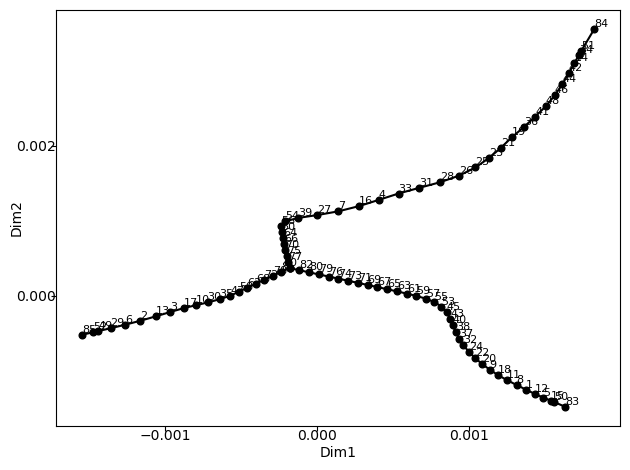

In [39]:
st.plot_branches(adata,show_text=True, n_components=2)

In [34]:
# ###Extend leaf branch to reach further cells 
# st.extend_elastic_principal_graph(adata, epg_ext_mode='WeigthedCentroid',epg_ext_par=0.8)
# st.plot_dimension_reduction(adata,n_components=2,show_graph=True,show_text=True)
# st.plot_branches(adata,show_text=False)

# Figure 4 traj plots

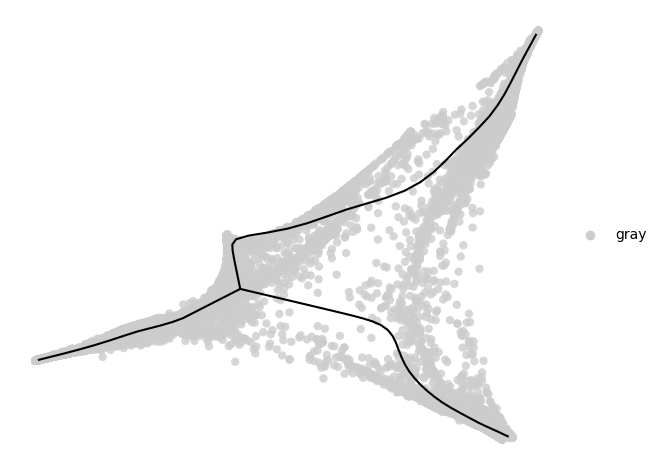

In [35]:
adata.obs['gray'] = 'gray'  # Create a column with value 'gray'
adata.uns['gray_color'] = {'gray': '#CCCCCC'} # Using a hex code for gray

fig = st.plot_dimension_reduction(adata, color=['gray'], n_components=2, show_graph=True, show_text=False)

# Get the current axes
ax = plt.gca()

# Remove ticks
ax.set_xticks([])
ax.set_yticks([])

# Remove spines (the box around the plot)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Remove title, legend, and labels
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')
plt.savefig(f"{config.DICTYS_FIGURES}/gray_bcell_traj.pdf", 
            bbox_inches='tight',  # Ensures the legend isn't cut off
            dpi=300,             # High resolution
            format='pdf')
plt.tight_layout()

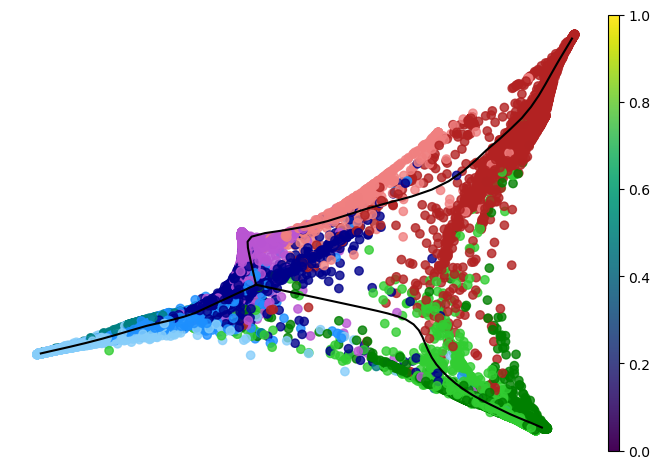

In [8]:
fig = st.plot_dimension_reduction(adata, color=['final_cell_colors'], n_components=2, show_graph=True, show_text=False)

# Get the current axes
ax = plt.gca()

# Remove ticks
ax.set_xticks([])
ax.set_yticks([])

# Remove spines (the box around the plot)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Remove title, legend, and labels
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')
plt.savefig(f"{config.DICTYS_FIGURES}/cell_state_bcell_traj.pdf", 
            bbox_inches='tight',  # Ensures the legend isn't cut off
            dpi=300,             # High resolution
            format='pdf')
plt.tight_layout()

#### Plot a subset of the adata to specify one state's differentiation

In [8]:
adata_subset = adata[adata.obs['branch_id_alias'].isin([('S3', 'S0'), ('S2', 'S0')])]

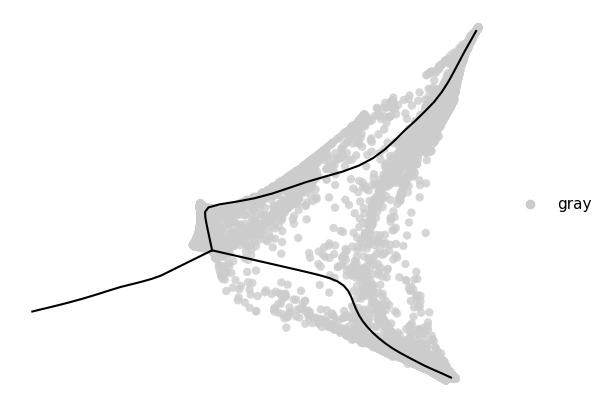

In [23]:
# give the obs gray gray color too in uns
adata_subset.uns['gray_color'] = {'gray': '#CCCCCC'}
# Then plot
fig = st.plot_dimension_reduction(adata_subset, color=['gray'], n_components=2, show_graph=True, show_text=False)

# Get the current axes
ax = plt.gca()

# Remove ticks
ax.set_xticks([])
ax.set_yticks([])

# Remove spines (the box around the plot)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Remove title, legend, and labels
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')
#save svg
plt.savefig(f"{config.DICTYS_FIGURES}/subset_bcell_traj.svg", 
            bbox_inches='tight',  # Ensures the legend isn't cut off
            dpi=300,             # High resolution
            format='svg')


# Verifying genes of interest's expression per branch on the trajectory

In [ ]:
# Convert categorical columns to ordered categorical
for col in ['Z11', 'Z3']:
    if pd.api.types.is_categorical_dtype(adata.obs[col]):
        adata.obs[col] = adata.obs[col].astype('category').cat.as_ordered()

# Now plot
st.plot_stream_sc(adata, root='S0', color=['TCF12', 'IRF4', 'PRDM1', 'XBP1', 'BATF', 'NFKB1', 'PAX5'], show_graph=True, show_text=True, save_fig=False, fig_path=config.FIGURES_SUPPL)
# save_fig=True, fig_path=config.FIGURES_SUPPL

In [13]:
adata.obs['S0_pseudotime']

index
AAACAGCCAAGCCACT-3    0.002726
AAACAGCCAAGGTGCA-1    0.000901
AAACAGCCAAGTTATC-1    0.001252
AAACAGCCAATAGCCC-1    0.001403
AAACAGCCAGTTAGCC-1    0.001313
                        ...   
TTTGTTGGTTTACGTC-1    0.001433
TTTGTTGGTTTAGTCC-1    0.001554
TTTGTTGGTTTATGGG-2    0.000273
TTTGTTGGTTTCCTCC-3    0.002681
TTTGTTGGTTTGAGGC-2    0.000115
Name: S0_pseudotime, Length: 28494, dtype: float64

In [49]:
# get max pseudotime for each branch
S1_max_pseudotime = adata.obs['S1_pseudotime'].max()
S2_max_pseudotime = adata.obs['S2_pseudotime'].max()
S3_max_pseudotime = adata.obs['S3_pseudotime'].max()
S0_max_pseudotime = adata.obs['S0_pseudotime'].max()
print(S1_max_pseudotime)
print(S2_max_pseudotime)
print(S3_max_pseudotime)
print(S0_max_pseudotime)


0.0057572311189962085
0.006857882774778135
0.006857882774778135
0.004109590594598965


In [45]:
# # save the S2_pseudotime with barcodes (taken from obs.index) to a csv
# pseudotime_df = pd.DataFrame({'Barcode': adata.obs.index, 'S1_pseudotime': adata.obs['S1_pseudotime']})
# pseudotime_df.to_csv(os.path.join(stream_outs_path,'S1_pseudotime.csv'), index=False)


In [47]:
# write stream adata to pkl
st.write(adata,file_name=os.path.join(out_dir,'mlle_traj_male_donor.pkl'))

## Dictys inputs

In [27]:
import numpy as np
import pandas as pd
# Extract node names from pseudotime columns
dimnodes=np.array(sorted([x[:-len('_pseudotime')] for x in adata.obs.columns if x.endswith('_pseudotime')]))
dist=np.array([adata.obs.loc[adata.obs.index,x+'_pseudotime'].values for x in dimnodes]).T
node_dict=dict(zip(dimnodes,range(len(dimnodes))))
branch = np.array([
    sorted([node_dict.get(y.strip('() \''), None) for y in x])
    for x in adata.obs['branch_id_alias']
])

# save the branch, edge, and dist files

# The branch each cell is on (cell:(node_start,node_end))
branch=pd.DataFrame(branch,index=adata.obs.index)
#display(branch)
branch.to_csv(os.path.join(stream_outs_path,'branch.tsv.gz'),header=False,index=False,sep='\t')

# Identify and save unique edges between nodes
edge=np.unique(branch.values,axis=0)
display(edge)
edge=pd.DataFrame(edge)
edge.to_csv(os.path.join(stream_outs_path,'edge.tsv.gz'),header=False,index=False,sep='\t')

# The distance of each cell to each node (cell:node, value is pseudotime distance)
dist=pd.DataFrame(dist,index=adata.obs.index,columns=dimnodes)
dist.to_csv(os.path.join(stream_outs_path,'dist.tsv.gz'),header=True,index=True,sep='\t')

array([[0, 1],
       [0, 2],
       [0, 3]])

#### Make subsets of the sub cell types

In [ ]:
adata.obs.sub_cell_type.to_csv(f'{dictys_data_path}/clusters.csv',header=['Cluster'],index=True,index_label='Barcode')

#### Make coord_rna.tsv.gz file of the cells and their lower dim coords, for dictys input

In [31]:
import anndata as ad
import pandas as pd

# Convert the obs.index (cell barcodes) to a DataFrame
obs_index_df = pd.DataFrame(adata.obs.index)
# Create a new AnnData object with only the cell barcodes and X_dr from obsm
adata_reduced = ad.AnnData(
    obs=obs_index_df,  # Use the cell barcodes as the obs DataFrame
    obsm={"X_dr": adata.obsm['X_dr']}  # Keep only 'X_dr' from obsm
)
# Confirm that the new AnnData object has the correct structure
adata_reduced

/ocean/projects/cis240075p/asachan/.conda/envs/env_stream/lib/python3.7/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 28494 × 0
    obs: 0
    obsm: 'X_dr'

In [32]:
import os
import pandas as pd

# Extract the relevant columns from the AnnData object
# The cell barcodes (obs.index) and 'X_dr' from obsm
cell_barcodes = adata.obs.index
xy_coords = adata_reduced.obsm['X_dr']

# Create a DataFrame with cell barcodes as the first column and 'X_dr' as the next columns
coord_df_b_cell = pd.DataFrame(data=xy_coords, columns=['x', 'y'])
coord_df_b_cell.insert(0, None, cell_barcodes)

#display the df
print(coord_df_b_cell.head())

                  NaN         x         y
0  AAACAGCCAAGCCACT-3  0.001589 -0.001502
1  AAACAGCCAAGGTGCA-1 -0.000893 -0.000170
2  AAACAGCCAAGTTATC-1 -0.001197 -0.000344
3  AAACAGCCAATAGCCC-1 -0.001334 -0.000409
4  AAACAGCCAGTTAGCC-1 -0.001249 -0.000377


In [33]:
# Save the DataFrame to a TSV file
output_path = os.path.join(dictys_data_path,'coord_rna.tsv.gz')
coord_df_b_cell.to_csv(output_path, sep='\t', compression='gzip', index=False, header=['', 'x', 'y'])

## Porting to adata to be used for downstream analysis

In [14]:
adata.obs['S0_pseudotime']

index
AAACAGCCAAGCCACT-3    0.002726
AAACAGCCAAGGTGCA-1    0.000901
AAACAGCCAAGTTATC-1    0.001252
AAACAGCCAATAGCCC-1    0.001403
AAACAGCCAGTTAGCC-1    0.001313
                        ...   
TTTGTTGGTTTACGTC-1    0.001433
TTTGTTGGTTTAGTCC-1    0.001554
TTTGTTGGTTTATGGG-2    0.000273
TTTGTTGGTTTCCTCC-3    0.002681
TTTGTTGGTTTGAGGC-2    0.000115
Name: S0_pseudotime, Length: 28494, dtype: float64

In [15]:
adata.obs['branch_id_alias']

index
AAACAGCCAAGCCACT-3    (S3, S0)
AAACAGCCAAGGTGCA-1    (S1, S0)
AAACAGCCAAGTTATC-1    (S1, S0)
AAACAGCCAATAGCCC-1    (S1, S0)
AAACAGCCAGTTAGCC-1    (S1, S0)
                        ...   
TTTGTTGGTTTACGTC-1    (S1, S0)
TTTGTTGGTTTAGTCC-1    (S1, S0)
TTTGTTGGTTTATGGG-2    (S1, S0)
TTTGTTGGTTTCCTCC-3    (S3, S0)
TTTGTTGGTTTGAGGC-2    (S2, S0)
Name: branch_id_alias, Length: 28494, dtype: object

In [17]:
import os
import pandas as pd

# Convert the obs.index (cell barcodes) to a DataFrame
obs_index_df = pd.DataFrame(adata.obs.index)
# Extract the relevant columns from the AnnData object
# The cell barcodes (obs.index) and 'X_dr' from obsm
cell_barcodes = adata.obs.index
xy_coords = adata.obsm['X_dr']
S0_pseudotime = adata.obs['S0_pseudotime']
branch_id_alias = adata.obs['branch_id_alias']


# Create a DataFrame with cell barcodes as the first column and 'X_dr' as the next columns and S0_pseudotime as the last column
adata_reduced_df = pd.DataFrame(data=xy_coords, columns=['x', 'y'])
adata_reduced_df.insert(0, 'cell_barcode', cell_barcodes)
adata_reduced_df['S0_pseudotime'] = S0_pseudotime.values        # .values strips the cell-barcode index
adata_reduced_df['branch_id_alias'] = branch_id_alias.values

#display the df
print(adata_reduced_df.head())

         cell_barcode         x         y  S0_pseudotime branch_id_alias
0  AAACAGCCAAGCCACT-3  0.001589 -0.001502       0.002726        (S3, S0)
1  AAACAGCCAAGGTGCA-1 -0.000893 -0.000170       0.000901        (S1, S0)
2  AAACAGCCAAGTTATC-1 -0.001197 -0.000344       0.001252        (S1, S0)
3  AAACAGCCAATAGCCC-1 -0.001334 -0.000409       0.001403        (S1, S0)
4  AAACAGCCAGTTAGCC-1 -0.001249 -0.000377       0.001313        (S1, S0)


In [18]:
# Save the DataFrame to a TSV file
output_path = f"{config.MALE_STREAM_OUTS}/actb1_added/adata_reduced.tsv.gz"
adata_reduced_df.to_csv(output_path, sep='\t', compression='gzip', index=False, header=['cell_barcode', 'x', 'y', 'S0_pseudotime', 'branch_id_alias'])